**End-to-End Natural Language Processing Pipeline: From Bag-of-Words to Transformers**

# **NLP**

In [16]:
# ===========================================
# 🧠 NLP Text Preprocessing
# ===========================================

import re # (Regular Expressions), Removing punctuation, Removing numbers,Replacing unwanted characters
import nltk  # (Natural Language Toolkit) provides Tokenizers, Stopwords, Stemmers & Lemmatizers, POS tagging, Named Entity Recognition
from nltk.tokenize import word_tokenize, sent_tokenize #( Splits paragraph → sentences, Splits sentence → words)
from nltk.corpus import stopwords #  Stopwords( is, the, and, in, on, at)
from nltk.stem import PorterStemmer, WordNetLemmatizer  # ( words to root form),() Converts words to dictionary base form)


# Download all required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')  # ✅ extra one to fix LookupError
nltk.download('words')
nltk.download('punkt_tab') # Added to resolve LookupError for punkt_tab
nltk.download('averaged_perceptron_tagger_eng') # Added to resolve LookupError for averaged_perceptron_tagger_eng


# This section initializes the NLP preprocessing environment using NLTK. It imports tokenization, stopword handling, stemming, lemmatization, POS tagging, and NER utilities, and explicitly downloads all required linguistic resources to avoid runtime lookup errors across different NLTK versions

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_percep

True

In [17]:
# -------------------------------------------
# 1️⃣ Text Cleaning Basics
# -------------------------------------------
text = "Hello!!! This   is an example...    NLP, isn't it???" # Raw text
clean_text = " ".join(text.split())       # remove extra spaces and Joins words back with exactly one space
print("1. Text Cleaning:\n", clean_text) # \n new line


1. Text Cleaning:
 Hello!!! This is an example... NLP, isn't it???


In [18]:
word_tokenize(clean_text)

# NLTK’s word_tokenize to split normalized text into linguistically meaningful tokens, preserving punctuation and contractions, which is important for downstream NLP tasks

# Clean Text-> word_tokenize()->Stopword Removal-> Stemming / Lemmatization->  Vectorization

['Hello',
 '!',
 '!',
 '!',
 'This',
 'is',
 'an',
 'example',
 '...',
 'NLP',
 ',',
 'is',
 "n't",
 'it',
 '?',
 '?',
 '?']

In [19]:
sent_tokenize(clean_text)
# handles punctuation and abbreviations more reliably than rule-based splitting

['Hello!!!', "This is an example... NLP, isn't it??", '?']

In [20]:
# -------------------------------------------
# 3️⃣ Normalization + Lowercasing
# -------------------------------------------
normalized = clean_text.lower()           # convert all to lowercase
print("\n3. Normalized Text:", normalized)

# This step that reduces vocabulary size by treating words with different cases as the same token, which improves model efficiency and generalization


3. Normalized Text: hello!!! this is an example... nlp, isn't it???


In [21]:
# -------------------------------------------
# 4️⃣ Removing Punctuation & Special Characters
# -------------------------------------------
no_punct = re.sub(r'[^a-zA-Z\s]', '', normalized)   # keep only letters and spaces
print("\n4. Removed Punctuations:", no_punct)


4. Removed Punctuations: hello this is an example nlp isnt it


In [22]:
words = word_tokenize(no_punct)
filtered_words = [w for w in words if w not in stopwords.words('english')]
print("\n5. Stopwords Removed:", filtered_words)

# Splits the cleaned, punctuation-free text (no_punct) into individual word tokens

# Stemming-> lemmatization-> vectorization are follows


5. Stopwords Removed: ['hello', 'example', 'nlp', 'isnt']


In [23]:
stemmer = PorterStemmer() # Does not consider grammar or meaning
lemmatizer = WordNetLemmatizer() # accurate and meaningful than stemming
sample_words = ["running", "studies", "better"]
print("\n6. Stemming vs Lemmatization:")
for w in sample_words:
    print(f"   {w:10} → stemmed: {stemmer.stem(w):10} | lemmatized: {lemmatizer.lemmatize(w)}")


6. Stemming vs Lemmatization:
   running    → stemmed: run        | lemmatized: running
   studies    → stemmed: studi      | lemmatized: study
   better     → stemmed: better     | lemmatized: better


In [24]:
# -------------------------------------------
# 7️⃣ POS Tagging
# POS tagging always works on tokens, not raw strings, improves accuracy significantly.
# -------------------------------------------
pos_tags = nltk.pos_tag(word_tokenize("The quick brown fox jumps over the lazy dog"))
print("\n7. POS Tags:", pos_tags)

#DT-> Determiner, JJ-> Adjective , NN-> Noun, VBZ-> Verb, IN-> Preposition

#POS tagging assigns grammatical labels to tokens, which enables linguistically aware processing such as accurate lemmatization, entity recognition, and syntactic analysis



7. POS Tags: [('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN')]


**BOW-CBOW**

In [25]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# Focuses on how many times a word appears,
# Converts text into TF-IDF scores, Highlights important and rare words
import pandas as pd
import numpy as np

# -------------------------------------------
# Sample Text Data
# docs is a corpus (collection of documents) , In real projects( Customer reviews, Telecom logs, )
# -------------------------------------------
docs = [
    "I love data science and machine learning",
    "Machine learning is part of data science",
    "I love learning new things"
]
print("Sample Documents:\n", docs)

Sample Documents:
 ['I love data science and machine learning', 'Machine learning is part of data science', 'I love learning new things']


In [26]:
# -------------------------------------------
#  Bag of Words (BoW)
# -------------------------------------------
vectorizer = CountVectorizer()           # converts text to word counts
# Tokenizes text, Builds a vocabulary of unique words, Counts how often each word appears in each document
bow_matrix = vectorizer.fit_transform(docs)
#Scans all documents, Builds the vocabulary, Assigns each word an index, Converts documents into numerical vectors

print(" Bag of Words (BoW) - Vocabulary:\n", vectorizer.get_feature_names_out())
print("\nBoW Matrix:\n", bow_matrix.toarray())    # matrix form (docs × words)

 Bag of Words (BoW) - Vocabulary:
 ['and' 'data' 'is' 'learning' 'love' 'machine' 'new' 'of' 'part' 'science'
 'things']

BoW Matrix:
 [[1 1 0 1 1 1 0 0 0 1 0]
 [0 1 1 1 0 1 0 1 1 1 0]
 [0 0 0 1 1 0 1 0 0 0 1]]


In [27]:
# -------------------------------------------
#  Using Sklearn's TF-IDF Vectorizer
# -------------------------------------------
tfidf_vectorizer = TfidfVectorizer() # It converts text into numerical vectors based on How often a word appears in a document, How rare the word is across all documents
# Words that appear in many documents get lower weight
tfidf_matrix = tfidf_vectorizer.fit_transform(docs) # build vocab and calculate IDF scores and coverts documents in to tf-idf vectors
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out()) # converts sparce matrix to Data frame
# TF-IDF Fits in NLP Pipeline for vectorization
print("TF-IDF (Sklearn Vectorizer):\n")
print(tfidf_df.round(3))

TF-IDF (Sklearn Vectorizer):

     and   data     is  learning   love  machine    new     of   part  \
0  0.523  0.397  0.000     0.309  0.397    0.397  0.000  0.000  0.000   
1  0.000  0.337  0.444     0.262  0.000    0.337  0.000  0.444  0.444   
2  0.000  0.000  0.000     0.345  0.445    0.000  0.584  0.000  0.000   

   science  things  
0    0.397   0.000  
1    0.337   0.000  
2    0.000   0.584  


**Language Modelling-N-Grams**

In [28]:
# -------------------------------------------
# N-grams (Unigram, Bigram, Trigram)
# -------------------------------------------
# Unigram (single words)
uni = CountVectorizer(ngram_range=(1,1)).fit(docs) # Initializes a Bag-of-Words vectorizer
# Defines minimum and maximum n-gram size
print("\n Unigrams:", uni.get_feature_names_out())

# Unigrams represent individual words as features and form the simplest Bag of Words model, capturing term frequency but ignoring word order and context


 Unigrams: ['and' 'data' 'is' 'learning' 'love' 'machine' 'new' 'of' 'part' 'science'
 'things']


In [29]:
# Bigram (pairs of words)
# Bigrams → capture short phrases
# Trigrams → capture richer context
bi = CountVectorizer(ngram_range=(2,2)).fit(docs) # (2,2) Minimum words per token = 2, Maximum words per token = 2
print(" Bigrams:", bi.get_feature_names_out())
# Bigrams capture relationships between adjacent words, enabling models to learn phrase-level meaning that unigrams fail to represent

 Bigrams: ['and machine' 'data science' 'is part' 'learning is' 'learning new'
 'love data' 'love learning' 'machine learning' 'new things' 'of data'
 'part of' 'science and']


In [30]:
# Trigram (3 consecutive words)
tri = CountVectorizer(ngram_range=(3,3)).fit(docs) # converts text into numerical features,sequence of 3 consicutive words
# fit(docs) ->Learns the vocabulary from docs
print("Trigrams:", tri.get_feature_names_out())

Trigrams: ['and machine learning' 'data science and' 'is part of' 'learning is part'
 'learning new things' 'love data science' 'love learning new'
 'machine learning is' 'of data science' 'part of data'
 'science and machine']


**WORD2VEC: CBOW & SKIP-GRAM**

In [31]:
# ===========================================
# 🧠 WORD2VEC: CBOW & SKIP-GRAM
# ===========================================
# Word2Vec->It captures semantic + syntactic relationships(king − man + woman ≈ queen)
# Install gensim library
# Used for Word2Vec implementation
!pip install gensim --quiet


# -------------------------------------------
# IMPORT REQUIRED LIBRARIES
# -------------------------------------------

import numpy as np                    # Numerical operations
import matplotlib.pyplot as plt       # Plotting embeddings

from gensim.models import Word2Vec    # Word2Vec model , it supports CBOW, SKIPGRAM, Softmax
from sklearn.manifold import TSNE     # Dimensionality reduction for visualization

# t-SNE-> As Word embeddings are usually 100–300 dimensions so t-SNE (300D → 2D)

#Word2Vec helps to understand word meanings by learning how words appear together, CBOW learns fast but shallow, Skip-Gram learns slower but deeper, and t-SNE lets humans visually confirm that similar words are grouped together

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.0 MB/s eta 0:00:00


In [32]:
# -------------------------------------------
# 1️⃣ SAMPLE TEXT CORPUS
# -------------------------------------------

# Small dataset of sentences
sentences = [
    "I love natural language processing",
    "Language models understand context",
    "Word embeddings capture semantic meaning",
    "Machine learning is fun"
]

# Tokenization:
# - Convert to lowercase
# - Split sentence into words
# Output format required by Word2Vec → list of word lists
tokenized = [s.lower().split() for s in sentences]

print("Tokenized Sentences:")
print(tokenized)

Tokenized Sentences:
[['i', 'love', 'natural', 'language', 'processing'], ['language', 'models', 'understand', 'context'], ['word', 'embeddings', 'capture', 'semantic', 'meaning'], ['machine', 'learning', 'is', 'fun']]


In [33]:
# -------------------------------------------
# 2️⃣ WORD2VEC – CBOW
# -------------------------------------------
# CBOW focuses on overall context, not rare edge cases
# CBOW (Continuous Bag of Words)
# Objective: Predict the target word using surrounding context words
# sg = 0 → CBOW architecture
cbow_model = Word2Vec(
    sentences=tokenized,   # Training data
    vector_size=50,        # Length of word embedding vector-Each word is converted into a vector of 50 numbers Smaller vector → faster, less detailed meaning, Larger vector → richer meaning, more memory
    window=3,              # Context window size-Look at 3 words on the left + 3 words on the right
    min_count=1,           # Include all words-If a word appears only 1 time → still include it
    sg=0,                  # CBOW
    workers=2              # Parallel training threads-Use 2 CPU cores to train faster
)

#sg = 0	CBOW
#sg = 1	Skip-Gram

# Display first 5 dimensions of the word vector
print("\nCBOW Vector for 'language' (first 5 values):")
print(cbow_model.wv["language"][:50])

#CBOW model learns word meanings by looking at nearby words and converts each word into a 50-number vector, allowing the computer to understand which words are related and how they are used in context


CBOW Vector for 'language' (first 5 values):
[-1.0724545e-03  4.7286271e-04  1.0206699e-02  1.8018546e-02
 -1.8605899e-02 -1.4233618e-02  1.2917745e-02  1.7945977e-02
 -1.0030856e-02 -7.5267432e-03  1.4761009e-02 -3.0669428e-03
 -9.0732267e-03  1.3108104e-02 -9.7203208e-03 -3.6320353e-03
  5.7531595e-03  1.9837476e-03 -1.6570430e-02 -1.8897636e-02
  1.4623532e-02  1.0140524e-02  1.3515387e-02  1.5257311e-03
  1.2701781e-02 -6.8107317e-03 -1.8928028e-03  1.1537147e-02
 -1.5043275e-02 -7.8722071e-03 -1.5023164e-02 -1.8600845e-03
  1.9076237e-02 -1.4638334e-02 -4.6675373e-03 -3.8754821e-03
  1.6154874e-02 -1.1861792e-02  9.0324880e-05 -9.5074680e-03
 -1.9207101e-02  1.0014586e-02 -1.7519170e-02 -8.7836506e-03
 -7.0199967e-05 -5.9236289e-04 -1.5322480e-02  1.9229487e-02
  9.9641159e-03  1.8466286e-02]


In [34]:
# -------------------------------------------
# 3️⃣ WORD2VEC – SKIP-GRAM
# -------------------------------------------

# Skip-gram model
# Objective: Predict surrounding context words using the target word
# sg = 1 → Skip-gram architecture
skipgram_model = Word2Vec(
    sentences=tokenized,
    vector_size=50,
    window=3, # Look at 3 words before and 3 words after the target word
    min_count=1,
    sg=1,                  # Skip-gram
    workers=2
)

# Display first 5 dimensions of the word vector
print("\nSkip-gram Vector for 'language' (first 5 values):")
print(skipgram_model.wv["language"][:5])

# Compared to CBOW, Skip-Gram learns deeper meaning, especially for rare words
# Skip-Gram predicts surrounding context words from a target word. It trains slower than CBOW but captures richer semantic relationships, especially for rare and domain-specific vocabulary


Skip-gram Vector for 'language' (first 5 values):
[-0.00107245  0.00047286  0.0102067   0.01801855 -0.0186059 ]


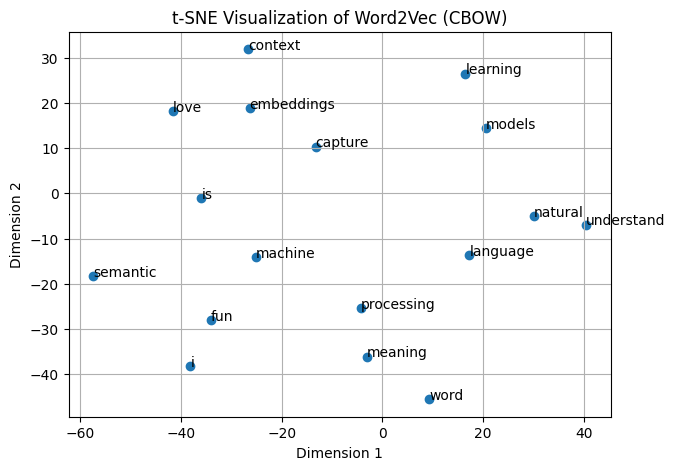

In [35]:
# -------------------------------------------
# 4️⃣ t-SNE VISUALIZATION (CBOW)
# -------------------------------------------
#Compresses those 50 numbers into 2 numbers (50Dimension-> 2D dimension)
# Extract all words from CBOW vocabulary
words = list(cbow_model.wv.index_to_key)

# Get embedding vectors for each word
X = np.array([cbow_model.wv[word] for word in words]) # Each word now has a numeric meaning now

# t-SNE perplexity must be less than number of data points
perplexity = min(5, len(words) - 1) # t-SNE needs a small value compared to the number of words

# Reduce 50D vectors into 2D space
# t-SNE focuses on keeping similar words close after compression.
tsne = TSNE(
    n_components=2,        # 2D visualization
    random_state=42,
    perplexity=perplexity,
    init="random",
    learning_rate="auto"
)

# Perform dimensionality reduction
X_2d = tsne.fit_transform(X)

# Plot the 2D embeddings
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1]) # each dot is 1 word and Distance between dots shows how related words are

# Label each point with the corresponding word
for i, word in enumerate(words):
    plt.annotate(word, (X_2d[i, 0], X_2d[i, 1])) # Makes it easy to visually confirm semantic relationships

plt.title("t-SNE Visualization of Word2Vec (CBOW)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

# t-SNE is used to reduce high-dimensional Word2Vec embeddings into 2D space for visualization. If semantically similar words cluster together, it validates the quality of learned embeddings

**TOPIC MODELING USING LDA**

In [36]:
# ===========================================
# 🧠 TOPIC MODELING USING LDA
# LDA works on numbers, not raw text.
# ===========================================
# Automatically finding hidden themes (topics) inside a large collection of text
# Install required library
!pip install gensim --quiet


# -------------------------------------------
# IMPORT LIBRARIES
# -------------------------------------------

import re                                   # Text cleaning
from gensim import corpora                  # Dictionary creation
from gensim.models import LdaModel          # LDA model Installs the gensim library, which provides an efficient implementation of LDA (Latent Dirichlet Allocation).

# LDA is an unsupervised topic modeling technique that represents documents as mixtures of topics and topics as distributions of words, enabling automatic discovery of latent themes in large text corpora

In [37]:
# -------------------------------------------
# 1️⃣ SAMPLE DOCUMENTS (CORPUS)
# -------------------------------------------

documents = [
    "I love machine learning and data science",
    "Python is great for data analysis and machine learning",
    "Deep learning is a part of machine learning",
    "I enjoy watching movies and listening to music",
    "Music and movies are great for entertainment"
]

print("Documents:")
for doc in documents:
    print("-", doc)


 # From these documents, LDA will automatically discover two main topics, topic 1 – Technology / ML, Topic 2 – Entertainment


Documents:
- I love machine learning and data science
- Python is great for data analysis and machine learning
- Deep learning is a part of machine learning
- I enjoy watching movies and listening to music
- Music and movies are great for entertainment


In [38]:
# -------------------------------------------
# 2️⃣ BASIC TEXT PREPROCESSING
# -------------------------------------------

# Lowercase + remove special characters
clean_docs = [
    re.sub(r"[^a-z ]", "", doc.lower()) # removes numbers, punctuation, special symbols
    for doc in documents
]

# Tokenization: split sentences into words
tokenized_docs = [doc.split() for doc in clean_docs] # Break each cleaned sentence into individual words

print("\nTokenized Documents:")
print(tokenized_docs)

# Preprocessing standardizes text by lowercasing, removing noise, and tokenizing, which improves topic coherence and model performance in LDA


Tokenized Documents:
[['i', 'love', 'machine', 'learning', 'and', 'data', 'science'], ['python', 'is', 'great', 'for', 'data', 'analysis', 'and', 'machine', 'learning'], ['deep', 'learning', 'is', 'a', 'part', 'of', 'machine', 'learning'], ['i', 'enjoy', 'watching', 'movies', 'and', 'listening', 'to', 'music'], ['music', 'and', 'movies', 'are', 'great', 'for', 'entertainment']]


In [39]:
# -------------------------------------------
# 3️⃣ CREATE DICTIONARY & CORPUS
# -------------------------------------------

# Create word-to-id mapping
dictionary = corpora.Dictionary(tokenized_docs)

# Convert documents into Bag-of-Words format
# (word_id, word_count)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

print("\nDictionary:")
print(dictionary.token2id)

print("\nCorpus (Bag of Words):")
print(corpus)

# The dictionary maps words to unique IDs, and the Bag-of-Words corpus represents each document as word-frequency pairs, which serves as the numerical input required for LDA


Dictionary:
{'and': 0, 'data': 1, 'i': 2, 'learning': 3, 'love': 4, 'machine': 5, 'science': 6, 'analysis': 7, 'for': 8, 'great': 9, 'is': 10, 'python': 11, 'a': 12, 'deep': 13, 'of': 14, 'part': 15, 'enjoy': 16, 'listening': 17, 'movies': 18, 'music': 19, 'to': 20, 'watching': 21, 'are': 22, 'entertainment': 23}

Corpus (Bag of Words):
[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1)], [(0, 1), (1, 1), (3, 1), (5, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1)], [(3, 2), (5, 1), (10, 1), (12, 1), (13, 1), (14, 1), (15, 1)], [(0, 1), (2, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1)], [(0, 1), (8, 1), (9, 1), (18, 1), (19, 1), (22, 1), (23, 1)]]


{'and': 0, 'data': 1, 'i': 2, 'learning': 3, ...}-
👉 A word → unique ID mapping,
Every unique word gets a number.

Why do we need this?

Because algorithms don’t understand words, they understand numbers.

Corpus (Bag of Words):

(word_id, frequency)
(0, 1) → word with ID 0 appears 1 time


In [40]:
# -------------------------------------------
# 4️⃣ TRAIN LDA MODEL
# -------------------------------------------

from gensim.models import LdaModel

# Create and train the LDA model
lda_model = LdaModel(

    corpus=corpus,        # Bag-of-Words data (word_id, frequency)
                           # LDA learns topics using word counts

    id2word=dictionary,   # Mapping from word_id → actual word
                           # Helps convert numeric topics back to readable words

    num_topics=2,         # Number of hidden topics to discover
                           # Here: 2 topics (e.g., ML/Data & Entertainment)

    random_state=42,      # Fixes randomness for reproducible results
                           # Same output every time you run the code

    passes=10             # Number of training iterations over the corpus
                           # More passes = more stable and refined topics
)

# LDA model is now trained and ready to extract topics

# LDA training analyzes word counts across documents multiple times to discover hidden themes, learning which words belong together as topics


In [41]:
topics = lda_model.print_topics(num_words=5)
print(topics)

[(0, '0.142*"learning" + 0.106*"machine" + 0.067*"is" + 0.067*"data" + 0.055*"and"'), (1, '0.102*"and" + 0.076*"music" + 0.076*"movies" + 0.074*"great" + 0.074*"for"')]


In [42]:
# -------------------------------------------
# 5️⃣ DISPLAY DISCOVERED TOPICS
# -------------------------------------------

# Print a heading before displaying topics
print("\nDiscovered Topics:")

# Get topics learned by the LDA model
# num_words = 5 → show top 5 important words per topic
topics = lda_model.print_topics(num_words=5)
print("topics learned by the LDA model:",topics)

# Loop through each discovered topic
for topic in topics:

    # Each topic is shown as:
    # (topic_id, "word1 + word2 + word3 + ...")
    # This represents the most important words of that topic
    print(topic)
# LDA topics are interpreted by examining the highest-probability words in each topic, which collectively describe the underlying theme of the documents.


Discovered Topics:
topics learned by the LDA model: [(0, '0.142*"learning" + 0.106*"machine" + 0.067*"is" + 0.067*"data" + 0.055*"and"'), (1, '0.102*"and" + 0.076*"music" + 0.076*"movies" + 0.074*"great" + 0.074*"for"')]
(0, '0.142*"learning" + 0.106*"machine" + 0.067*"is" + 0.067*"data" + 0.055*"and"')
(1, '0.102*"and" + 0.076*"music" + 0.076*"movies" + 0.074*"great" + 0.074*"for"')


(topic_id, 'probability*"word" + probability*"word" + ...')
So LDA is saying:“For this topic, these words are most likely to appear.”

| Word     | Probability | Meaning            |
| -------- | ----------- | ------------------ |
| learning | 0.142       | Very important     |
| machine  | 0.106       | Highly related     |
| is       | 0.067       | Common helper word |
| data     | 0.067       | Domain word        |
| and      | 0.055       | Connecting word    |


In [43]:
# -------------------------------------------
# 6️⃣ TOPIC ASSIGNMENT FOR EACH DOCUMENT
# -------------------------------------------

# Print heading for clarity
print("\nDocument → Topic Distribution:")

# Loop through each document in the corpus
for i, doc in enumerate(corpus):

    # get_document_topics(doc) returns:
    # [(topic_id, probability), (topic_id, probability)]
    # showing how much each topic contributes to the document
    print(
        f"Document {i+1}:",
        lda_model.get_document_topics(doc)
    )



Document → Topic Distribution:
Document 1: [(0, np.float32(0.9213498)), (1, np.float32(0.0786502))]
Document 2: [(0, np.float32(0.44455472)), (1, np.float32(0.5554453))]
Document 3: [(0, np.float32(0.94204783)), (1, np.float32(0.05795215))]
Document 4: [(0, np.float32(0.061198752)), (1, np.float32(0.9388013))]
Document 5: [(0, np.float32(0.065662734)), (1, np.float32(0.9343373))]


Document X: [(topic_id, probability), (topic_id, probability)]

topic_id → Topic number discovered by LDA

probability → How much that topic contributes to the document

Probabilities for a document sum to 1

| Document   | Topic 0 (ML / Data) | Topic 1 (Entertainment) | Dominant Topic |
| ---------- | ------------------- | ----------------------- | -------------- |
| Document 1 | 0.92                | 0.08                    | Topic 0        |
| Document 2 | 0.44                | 0.56                    | Topic 1        |
| Document 3 | 0.94                | 0.06                    | Topic 0        |
| Document 4 | 0.06                | 0.94                    | Topic 1        |
| Document 5 | 0.07                | 0.93                    | Topic 1        |


**RNN | LSTM | Attention | Transformer | BERT**

In [44]:

import tensorflow as tf
from tensorflow.keras.models import Sequential # Used to build models layer by layer.
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM
#Embedding → converts words to numbers with meaning, SimpleRNN → basic sequence learner,LSTM → advanced RNN that remembers long context
from tensorflow.keras.preprocessing.text import Tokenizer # Converts words into numeric IDs.
from tensorflow.keras.preprocessing.sequence import pad_sequences # Makes all sentences the same length (required by neural networks)

# --------------------------------------------
# 1️⃣ INPUT SENTENCES
# --------------------------------------------

sentences = [
    "I love NLP",
    "NLP is fun"
]

print("Input Sentences:")
print(sentences)

# These input sentences provide simple sequential text so an RNN or LSTM can learn how words appear in order and form meaningful sentences

Input Sentences:
['I love NLP', 'NLP is fun']


In [45]:
# --------------------------------------------
# 2️⃣ WORDS → NUMBERS
# --------------------------------------------
tokenizer = Tokenizer()
# Creates a tokenizer object to convert words into numbers , each word assigned unique number

tokenizer.fit_on_texts(sentences)
# Reads all sentences and assigns a unique number to each word, Words that appear more often usually get lower numbers

sequences = tokenizer.texts_to_sequences(sentences)
# Replaces each word in the sentence with its assigned number, Replaces words with numbers.

X = pad_sequences(sequences)
# Makes all sentences the same length by adding zeros in front ie if diffrent lengths

print("\nTokenized Sentences (Words → Numbers):")
# Label for output display

print(X)


Tokenized Sentences (Words → Numbers):
[[2 3 1]
 [1 4 5]]


In [46]:
vocab_size = 50 # It will allow up to 50 unique words in my vocabulary

In [47]:

# --------------------------------------------
# 3️⃣ EMBEDDING LAYER (WORDS → VECTORS)
# --------------------------------------------
# The Embedding layer converts word IDs into dense vectors that capture meaning.

embedding_layer = Embedding(
    input_dim=vocab_size,   # Vocabulary size
    output_dim=8            # Each word → 8 numbers
)
# (2 sentences, 3 words each, 8 numbers per word) → (2, 3, 8)
embedded_output = embedding_layer(X)

print("\nEmbedding Output Shape:")
print(embedded_output.shape)
# (sentences, words, embedding_dim)

print("\nEmbedding Output:")
print(embedded_output)

# The embedding layer transforms word IDs into small numeric vectors that capture semantic meaning, preparing them for sequential models like RNN/LSTM.


Embedding Output Shape:
(2, 3, 8)

Embedding Output:
tf.Tensor(
[[[-0.04811064 -0.04282867 -0.02569312 -0.01427981 -0.0071891
    0.00813013  0.01492793 -0.03671423]
  [-0.02616211  0.02641926 -0.0467627  -0.04120884 -0.04237217
    0.01597149 -0.0318092  -0.01735212]
  [-0.01565079  0.01194273  0.03543263  0.03139291 -0.02055836
    0.01123844  0.04944636  0.04064807]]

 [[-0.01565079  0.01194273  0.03543263  0.03139291 -0.02055836
    0.01123844  0.04944636  0.04064807]
  [-0.04960329 -0.02302018 -0.02718772 -0.02580577  0.03443934
   -0.04489119  0.00800183 -0.02507444]
  [ 0.00936937  0.00571829  0.04168839  0.00240193 -0.03117925
    0.04738354 -0.00362812 -0.01764116]]], shape=(2, 3, 8), dtype=float32)


In [48]:
# --------------------------------------------
# 4️⃣ RNN MODEL
# --------------------------------------------
# RNN remembers previous words while processing the current word, Captures order of words,Learns dependencies.
# Memory units store previous context information for each word
#RNN layer reads sequential input, maintaining hidden states that capture contextual information from previous time steps, producing a context-aware representation for each word in the sequence
rnn_model = Sequential([
    Embedding(vocab_size, 8),          # Word embeddings
    SimpleRNN(16, return_sequences=True),  # 16 RNN memory units, return_sequences=True → output for every word
])



rnn_output = rnn_model(X)

print("\nRNN Output Shape:")
print(rnn_output.shape)
# (sentences, words, 16)

print("\nRNN Output:")
print(rnn_output)


RNN Output Shape:
(2, 3, 16)

RNN Output:
tf.Tensor(
[[[ 0.07510033 -0.01437403 -0.00177376 -0.01757803 -0.02358968
    0.0198876   0.02665665  0.0174011  -0.00305751  0.02662866
   -0.03423538 -0.05394522 -0.00357005  0.00448405  0.00685299
   -0.01646154]
  [-0.01914786  0.01094758  0.00492017  0.02128064 -0.04767491
    0.04263853  0.03237116 -0.03503682 -0.02852073  0.010934
    0.01693806 -0.01005936 -0.01409423 -0.04160337  0.02169386
   -0.05691105]
  [-0.00661571  0.11808025 -0.05112567 -0.05036972  0.02450081
    0.00117664  0.02168737 -0.01972466  0.02798567 -0.01235591
   -0.02867695  0.01733139 -0.03647883  0.07355228  0.03573335
    0.0372148 ]]

 [[ 0.03481112  0.05638024 -0.02179213 -0.03035054  0.02220325
    0.02811578 -0.0022145  -0.00677465  0.04737241 -0.00861764
   -0.01596175  0.01901952 -0.00203466  0.03033779  0.01153202
   -0.0047355 ]
  [-0.0452378  -0.0178004   0.02836154  0.02356294  0.01503958
    0.07923118 -0.02258693 -0.00430175  0.05143089  0.05155971


In [49]:
# --------------------------------------------
# 5️⃣ LSTM MODEL
# --------------------------------------------

lstm_model = Sequential([
    Embedding(vocab_size, 8),          # Word embeddings, Converts word IDs → 8-dimensional vectors
    LSTM(16, return_sequences=True),   # 16 LSTM memory units, 16 memory units (neurons) that process the sequence,outputs a vector for each word
])
#Each word vector now contains context-aware information, LSTM decides what to remember and what to forget from previous words

lstm_output = lstm_model(X)

print("\nLSTM Output Shape:")
print(lstm_output.shape)
# (sentences, words, 16)

print("\nLSTM Output:")
print(lstm_output)
# Shape: (2 sentences, 3 words, 16 memory units)
# Captures order of words, Maintains long-term dependencies, Learns which information to keep or forget
# Forget mechanism not there in RNN, in LSTM Gates control forget/remember


LSTM Output Shape:
(2, 3, 16)

LSTM Output:
tf.Tensor(
[[[-7.9407262e-05  2.7107834e-03 -5.4627880e-03 -1.4898172e-03
   -6.2461914e-03  3.9751490e-04 -7.1701994e-03  7.3233154e-03
    4.7416249e-03 -3.9695571e-03  4.6557076e-03 -5.2189287e-03
   -1.9299999e-03 -3.0422788e-03  3.6945767e-03  6.1746417e-03]
  [ 5.0390940e-03  2.1836546e-03 -7.4971293e-05 -2.5220963e-03
   -6.9864830e-03  1.5457626e-03 -4.6172091e-03  5.0823842e-03
    6.0953978e-03 -2.9686154e-03  2.0967158e-03 -2.9762497e-03
   -7.2348798e-03  4.1254675e-03  6.9893859e-03  1.7592150e-03]
  [ 7.9618497e-03  9.5333450e-04 -5.3270865e-04 -3.7504158e-03
   -1.3541762e-02  1.6983076e-04 -5.4449257e-03  2.0933584e-03
    5.3739795e-03 -3.2136659e-03  1.9227951e-03 -6.9441963e-03
   -8.5187256e-03  3.9121676e-03  1.2978719e-02 -2.2674449e-04]]

 [[ 3.8957330e-03 -3.6336685e-04  3.8469494e-05 -2.6050878e-03
   -9.1838147e-03 -6.2549760e-04 -2.3907172e-03 -2.3197322e-03
   -1.2758042e-04 -2.1806640e-05 -2.0360088e-04 -4.531556

LSTM

---

## What is this diagram?

It shows **how an LSTM (Long Short-Term Memory) cell works at one time step**.

An LSTM is used in **sequence data** (text, speech, time series) to **remember important information and forget unnecessary information**.

---

## Inputs coming into the LSTM

* **(x_t)** → current input (current word / value)
* **(h_{t-1})** → previous hidden state (short-term memory)
* **(C_{t-1})** → previous cell state (long-term memory)

---

## 1️⃣ Forget Gate (What to forget?)

* Looks at **(x_t)** and **(h_{t-1})**
* Uses **sigmoid (σ)** → outputs values between **0 and 1**
* Multiplies with **(C_{t-1})**

👉

* **0** → forget completely
* **1** → keep completely

**Purpose:** Remove useless old information.

---

## 2️⃣ Input Gate (What new info to add?)

Two parts:

* **Sigmoid (σ)** → decides *how much* new info to allow
* **tanh** → creates *new candidate information*

Both are multiplied and **added to the cell state**.

👉
**Purpose:** Decide what new information should be stored.

---

## 3️⃣ Cell State Update

* Old memory (after forgetting)
* PLUS new selected information

This becomes the **new cell state (C_t)**
👉 This is the **long-term memory highway**

---

## 4️⃣ Output Gate (What to output?)

* Uses **sigmoid (σ)** to decide what part of memory to show
* Applies **tanh** on cell state
* Produces **(h_t)** (hidden state / output)

👉
**Purpose:** Decide what information to pass to the next step or prediction.

---

## Final Outputs

* **(C_t)** → updated long-term memory
* **(h_t)** → output + short-term memory

---

## One-line student summary ✅

> **LSTM uses gates to forget useless past data, add important new data, and output only what is needed — helping it remember long-term patterns.**



In [50]:

import tensorflow as tf
from tensorflow.keras.layers import Embedding, Attention, MultiHeadAttention
#Attention → simple attention mechanism, MultiHeadAttention → more advanced, used in Transformers
# ----------------------------------------------------------
# 4️⃣ ATTENTION / SELF-ATTENTION
# ----------------------------------------------------------
# Self-attention lets each word look at all other words in a sentence, producing context-aware vectors that emphasize important words and relationships
attention_layer = Attention()
# Creates an Attention layer that learns to focus on important words

attention_output = attention_layer([embedded_output, embedded_output])# This means each word looks at every other word in the sentence
# Applies self-attention: Each word checks every other word
# Query = embedded_output  # word asking “which words matter?”
# Key   = embedded_output , word being considered
# Value = embedded_output, word embedding information
#Output = weighted combination of all words for each word


print("\nSelf-Attention Output Shape:")
print(attention_output.shape)

print("\nSelf-Attention Output:")
print(attention_output)
# Each word vector now contains context-aware information, weighted by attention

# The Attention layer computes weighted sums of word embeddings where each word (query) attends to all other words (keys/values), enabling context-dependent representations essential for Transformers
# Attention is single-head
# MultiHeadAttention → multiple attention heads, captures different aspects of context
# Self-Attention Output Shape:(2, 3, 8) 2 sentances, 3 words per sentance, 8 embedding dimensions
# Self-attention keeps the same shape but enriches each word vector with information from all other words in the sentence.


Self-Attention Output Shape:
(2, 3, 8)

Self-Attention Output:
tf.Tensor(
[[[-0.03001964 -0.00156524 -0.01242563 -0.00809502 -0.02335445
    0.01177566  0.01080751 -0.00458009]
  [-0.02999512 -0.00145845 -0.01250619 -0.00817794 -0.02341764
    0.01178967  0.01069125 -0.00458857]
  [-0.02993421 -0.00146582 -0.01217811 -0.00789455 -0.02335334
    0.01177587  0.01099566 -0.00433073]]

 [[-0.0185727  -0.00172674  0.01674992  0.00276204 -0.00585834
    0.00466914  0.01801423 -0.00057348]
  [-0.01875987 -0.00187092  0.01646528  0.00255473 -0.00560056
    0.00436763  0.01791271 -0.00077376]
  [-0.01852882 -0.00173251  0.01676731  0.00272264 -0.00588178
    0.00473337  0.0179346  -0.00065854]]], shape=(2, 3, 8), dtype=float32)


In [51]:
# ----------------------------------------------------------
# 5️⃣ TRANSFORMER (MULTI-HEAD SELF-ATTENTION)
# ----------------------------------------------------------
# Multi-Head Attention is like having multiple brains looking at the same sentence.one head may focus grammer, other focus on meaning
#This is the core idea behind Transformers, BERT, GPT, Multi-head attention does not change sequence length or embedding size
#Multi-head self-attention allows each word to understand other words from multiple perspectives, creating richer and more powerful representations
# RNN / LSTM sequential processing but transformer is parallel processing with Attention mechanism
transformer_attention = MultiHeadAttention(
    num_heads=2,      # Number of attention heads, Two parallel attention mechanisms
    key_dim=8         # Size of attention vectors, Size of Query/Key vectors per head
)

transformer_output = transformer_attention(
    embedded_output, embedded_output## This means each word looks at every other word in the sentence
)
# Transformer-style self-attentionThis is the core idea behind Transformers, BERT, GPT

print("\nTransformer Output Shape:")
print(transformer_output.shape)

print("\nTransformer Output:")
print(transformer_output)


Transformer Output Shape:
(2, 3, 8)

Transformer Output:
tf.Tensor(
[[[-0.00246278  0.00149551  0.0020292  -0.00404255  0.00738728
   -0.00427906  0.00818206 -0.01013506]
  [-0.00246165  0.00149286  0.00203153 -0.00404044  0.00738902
   -0.0042809   0.00818213 -0.01013377]
  [-0.00246146  0.00149441  0.00203041 -0.00404111  0.00738721
   -0.00428142  0.00818178 -0.01013398]]

 [[ 0.00169053 -0.00081496  0.00263083 -0.00430497  0.00508243
   -0.00119911  0.0039086  -0.00547844]
  [ 0.00168608 -0.00081804  0.00263548 -0.00429757  0.00508273
   -0.00119724  0.00390302 -0.00547586]
  [ 0.00168859 -0.00081618  0.00263152 -0.00430242  0.00508307
   -0.00119931  0.00390651 -0.00547684]]], shape=(2, 3, 8), dtype=float32)
